<a href="https://colab.research.google.com/github/Shreya-hub927/Students-performance-analysis-/blob/main/ecommerce_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sqlite3

# Connect to an in-memory SQLite database
# To make it persistent, replace ':memory:' with a filename like 'ecommerce.db'
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Create table
# 'CREATE DATABASE' and 'USE database' are not directly applicable to sqlite3 in this manner;
# the database is created/selected when connecting.
cursor.execute("""
CREATE TABLE ecommerce_data (
    OrderID INT PRIMARY KEY,
    CustomerName VARCHAR(50),
    City VARCHAR(50),
    Product VARCHAR(50),
    Category VARCHAR(50),
    Amount INT,
    Quantity INT,
    OrderDate DATE
);
""")

# Insert data
insert_data = [
    (101,'Aisha','Lucknow','Laptop','Electronics',55000,1,'2024-01-10'),
    (102,'Rahul','Delhi','Mobile','Electronics',20000,2,'2024-01-12'),
    (103,'Neha','Mumbai','Shoes','Fashion',3000,1,'2024-01-15'),
    (104,'Aman','Delhi','T-shirt','Fashion',1000,3,'2024-01-18'),
    (105,'Sara','Lucknow','Headphones','Electronics',2500,2,'2024-01-20'),
    (106,'Vikram','Mumbai','Watch','Accessories',5000,1,'2024-01-22'),
    (107,'Pooja','Delhi','Laptop','Electronics',60000,1,'2024-01-25'),
    (108,'Arjun','Lucknow','Shoes','Fashion',3500,2,'2024-01-28')
]

cursor.executemany("INSERT INTO ecommerce_data VALUES (?, ?, ?, ?, ?, ?, ?, ?)", insert_data)

# Commit changes and close connection
conn.commit()
conn.close()

print("Database 'ecommerce_db' (in-memory SQLite) created and populated successfully.")

Database 'ecommerce_db' (in-memory SQLite) created and populated successfully.


In [4]:
import pandas as pd

# Define column names based on the ecommerce_data table schema
columns = ['OrderID', 'CustomerName', 'City', 'Product', 'Category', 'Amount', 'Quantity', 'OrderDate']

# Create DataFrame from insert_data with specified column names
df = pd.DataFrame(insert_data, columns=columns)
display(df)

,OrderID,CustomerName,City,Product,Category,Amount,Quantity,OrderDate
0,101,Aisha,Lucknow,Laptop,Electronics,55000,1,2024-01-10
1,102,Rahul,Delhi,Mobile,Electronics,20000,2,2024-01-12
2,103,Neha,Mumbai,Shoes,Fashion,3000,1,2024-01-15
3,104,Aman,Delhi,T-shirt,Fashion,1000,3,2024-01-18
4,105,Sara,Lucknow,Headphones,Electronics,2500,2,2024-01-20
5,106,Vikram,Mumbai,Watch,Accessories,5000,1,2024-01-22
6,107,Pooja,Delhi,Laptop,Electronics,60000,1,2024-01-25
7,108,Arjun,Lucknow,Shoes,Fashion,3500,2,2024-01-28


In [6]:
import pandas as pd

# Sort the DataFrame by 'Amount' in descending order
df_sorted = df.sort_values(by='Amount', ascending=False)

# Display the sorted DataFrame
display(df_sorted)

,OrderID,CustomerName,City,Product,Category,Amount,Quantity,OrderDate
6,107,Pooja,Delhi,Laptop,Electronics,60000,1,2024-01-25
0,101,Aisha,Lucknow,Laptop,Electronics,55000,1,2024-01-10
1,102,Rahul,Delhi,Mobile,Electronics,20000,2,2024-01-12
5,106,Vikram,Mumbai,Watch,Accessories,5000,1,2024-01-22
7,108,Arjun,Lucknow,Shoes,Fashion,3500,2,2024-01-28
2,103,Neha,Mumbai,Shoes,Fashion,3000,1,2024-01-15
4,105,Sara,Lucknow,Headphones,Electronics,2500,2,2024-01-20
3,104,Aman,Delhi,T-shirt,Fashion,1000,3,2024-01-18


In [8]:
import pandas as pd

# Sort the DataFrame by 'OrderDate'
df_sorted_by_date = df.sort_values(by='OrderDate')

# Display the sorted DataFrame
display(df_sorted_by_date)

,OrderID,CustomerName,City,Product,Category,Amount,Quantity,OrderDate
0,101,Aisha,Lucknow,Laptop,Electronics,55000,1,2024-01-10
1,102,Rahul,Delhi,Mobile,Electronics,20000,2,2024-01-12
2,103,Neha,Mumbai,Shoes,Fashion,3000,1,2024-01-15
3,104,Aman,Delhi,T-shirt,Fashion,1000,3,2024-01-18
4,105,Sara,Lucknow,Headphones,Electronics,2500,2,2024-01-20
5,106,Vikram,Mumbai,Watch,Accessories,5000,1,2024-01-22
6,107,Pooja,Delhi,Laptop,Electronics,60000,1,2024-01-25
7,108,Arjun,Lucknow,Shoes,Fashion,3500,2,2024-01-28


In [10]:
import pandas as pd

# Group the DataFrame by 'Category' and calculate the sum of 'Amount'
sales_by_category = df.groupby('Category')['Amount'].sum().reset_index()
sales_by_category.columns = ['Category', 'Total_Sales']

# Display the result
display(sales_by_category)

,Category,Total_Sales
0,Accessories,5000
1,Electronics,137500
2,Fashion,7500


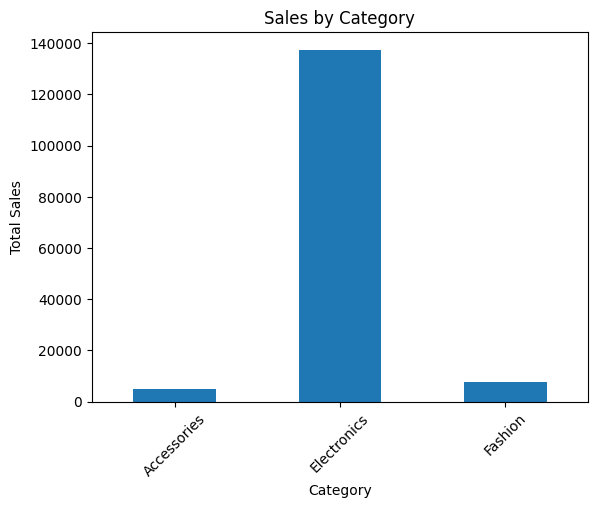

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Data to re-create df
insert_data = [
    (101,'Aisha','Lucknow','Laptop','Electronics',55000,1,'2024-01-10'),
    (102,'Rahul','Delhi','Mobile','Electronics',20000,2,'2024-01-12'),
    (103,'Neha','Mumbai','Shoes','Fashion',3000,1,'2024-01-15'),
    (104,'Aman','Delhi','T-shirt','Fashion',1000,3,'2024-01-18'),
    (105,'Sara','Lucknow','Headphones','Electronics',2500,2,'2024-01-20'),
    (106,'Vikram','Mumbai','Watch','Accessories',5000,1,'2024-01-22'),
    (107,'Pooja','Delhi','Laptop','Electronics',60000,1,'2024-01-25'),
    (108,'Arjun','Lucknow','Shoes','Fashion',3500,2,'2024-01-28')
]
columns = ['OrderID', 'CustomerName', 'City', 'Product', 'Category', 'Amount', 'Quantity', 'OrderDate']
df = pd.DataFrame(insert_data, columns=columns)

category_sales = df.groupby('Category')['Amount'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

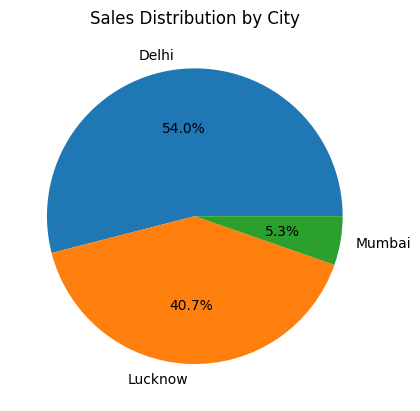

In [10]:
city_sales = df.groupby('City')['Amount'].sum()

plt.figure()
city_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by City")
plt.ylabel("")
plt.show()

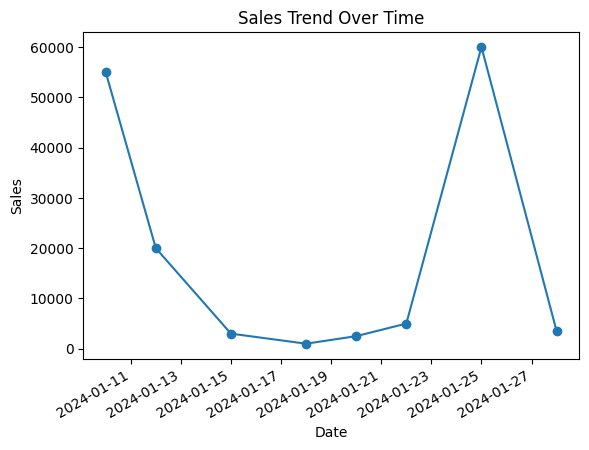

In [11]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
date_sales = df.groupby('OrderDate')['Amount'].sum()

plt.figure()
date_sales.plot(kind='line', marker='o')
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

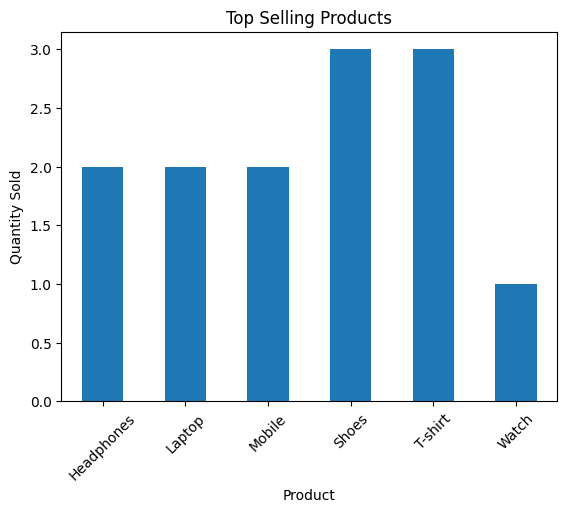

In [12]:
product_sales = df.groupby('Product')['Quantity'].sum()

plt.figure()
product_sales.plot(kind='bar')
plt.title("Top Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

In [ ]:
import pandas as pd
import sqlite3

# Re-establish connection to an in-memory SQLite database
# Since the previous in-memory database was closed and its content lost,
# we need to re-create it and re-insert the data.
conn = sqlite3.connect(':memory:')
cursor = conn.cursor()

# Re-create table schema
cursor.execute("""
CREATE TABLE ecommerce_data (
    OrderID INT PRIMARY KEY,
    CustomerName VARCHAR(50),
    City VARCHAR(50),
    Product VARCHAR(50),
    Category VARCHAR(50),
    Amount INT,
    Quantity INT,
    OrderDate DATE
);
""")

# Assuming 'insert_data' variable is still available from previous cell execution.
# If not, it would need to be defined here.
# insert_data = [
#     (101,'Aisha','Lucknow','Laptop','Electronics',55000,1,'2024-01-10'),
#     (102,'Rahul','Delhi','Mobile','Electronics',20000,2,'2024-01-12'),
#     (103,'Neha','Mumbai','Shoes','Fashion',3000,1,'2024-01-15'),
#     (104,'Aman','Delhi','T-shirt','Fashion',1000,3,'2024-01-18'),
#     (105,'Sara','Lucknow','Headphones','Electronics',2500,2,'2024-01-20'),
#     (106,'Vikram','Mumbai','Watch','Accessories',5000,1,'2024-01-22'),
#     (107,'Pooja','Delhi','Laptop','Electronics',60000,1,'2024-01-25'),
#     (108,'Arjun','Lucknow','Shoes','Fashion',3500,2,'2024-01-28')
# ]
cursor.executemany("INSERT INTO ecommerce_data VALUES (?, ?, ?, ?, ?, ?, ?, ?)", insert_data)
conn.commit()

query = "SELECT * FROM ecommerce_data"
df = pd.read_sql(query, conn)

print(df.head())

# Close the connection after use
conn.close()